In [ ]:
import os
import cv2
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
import warnings
import mediapipe as mp  # for face detection if needed
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

# -------------------------
# Data Augmentation Functions
# -------------------------
def random_horizontal_flip(image, keypoints, p=0.5, flip_pairs=None):
    """
    Randomly flips the image horizontally with probability p.
    Adjusts keypoints accordingly and swaps symmetric pairs if provided.
    Returns the (possibly flipped) image, adjusted keypoints, and a flag indicating a flip.
    """
    flipped = False
    if keypoints is not None and random.random() < p:
        flipped = True
        # Flip image horizontally
        image = cv2.flip(image, 1)
        w = image.shape[1]
        # Mirror the x coordinates
        keypoints[:, 0] = w - keypoints[:, 0]
        # Swap symmetric keypoints if mapping provided
        if flip_pairs is not None:
            kp_copy = keypoints.copy()
            for i, j in flip_pairs:
                keypoints[i, :], keypoints[j, :] = kp_copy[j, :], kp_copy[i, :]
    return image, keypoints, flipped

def random_rotation(image, keypoints, angle_range=(-15, 15)):
    angle = random.uniform(*angle_range)
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    rot_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, rot_matrix, (w, h))
    rotated_kp = None
    if keypoints is not None:
        ones = np.ones((keypoints.shape[0], 1))
        kp_homog = np.hstack([keypoints, ones])
        rotated_kp = np.dot(rot_matrix, kp_homog.T).T
    return rotated_image, rotated_kp

def load_pts(path):
    """Reads a .pts file and returns a NumPy array of points."""
    with open(path) as f:
        rows = [row.strip() for row in f]
    head = rows.index('{') + 1
    tail = rows.index('}')
    raw_points = rows[head:tail]
    coords_set = [point.split() for point in raw_points]
    points = np.array([[float(num) for num in coords] for coords in coords_set])
    return points

# -------------------------
# Helper Functions for Image Processing
# -------------------------
def get_img_tensor(pil_img, target_size, transform):
    iw, ih = pil_img.size
    if iw != target_size[0] or ih != target_size[1]:
        pil_img = pil_img.resize(target_size, Image.Resampling.BICUBIC)
    tensor_img = transform(pil_img)
    tensor_img = torch.unsqueeze(tensor_img, 0)
    return tensor_img

def cut_resize_letterbox(image, bbox, target_size):
    facebox_x, facebox_y, facebox_x2, facebox_y2 = bbox
    facebox_w = facebox_x2 - facebox_x
    facebox_h = facebox_y2 - facebox_y
    facebox_max_length = max(facebox_w, facebox_h)
    width_margin = (facebox_max_length - facebox_w) / 2
    height_margin = (facebox_max_length - facebox_h) / 2

    square_x = facebox_x - width_margin
    square_y = facebox_y - height_margin
    square_w = facebox_max_length
    square_h = facebox_max_length

    iw, ih = image.size
    top = -square_y if square_y < 0 else 0
    left = -square_x if square_x < 0 else 0
    bottom = (square_y + square_h - ih) if (square_y + square_h) > ih else 0
    right = (square_x + square_w - iw) if (square_x + square_w) > iw else 0

    padded_img = Image.new('RGB', (iw + left + right, ih + top + bottom), (0, 0, 0))
    padded_img.paste(image, (left, top))

    square_x += left
    square_y += top
    face_crop = padded_img.crop((int(square_x), int(square_y), int(square_x + square_w), int(square_y + square_h)))
    face_letterbox = face_crop.resize(target_size, Image.Resampling.BICUBIC)
    scale_l = facebox_max_length / target_size[0]
    return face_letterbox, scale_l, square_x, square_y

# -------------------------
# Process a Frame using Annotation-Based Cropping (68 keypoints)
# -------------------------
def process_frame_using_annotation(frame, annots_path, target_size=(224,224), margin=0.1):
    """
    Processes a frame by:
      - Loading the annotation (.pts) file containing 68 keypoints.
      - Computing a bounding box around the landmarks and adding a margin.
      - Cropping and resizing the face.
      - Adjusting keypoint coordinates.
      - Applying data augmentations (horizontal flip with proper symmetric swaps and rotation).
      
    Returns:
      resized_face: The processed face image (BGR format).
      annots_adjusted: The adjusted 68 keypoints in the processed image.
    """
    if os.path.exists(annots_path):
        annots = load_pts(annots_path)
        annots = np.array(annots)
    else:
        annots = None
    
    if annots is not None:
        min_x = int(np.min(annots[:, 0]))
        max_x = int(np.max(annots[:, 0]))
        min_y = int(np.min(annots[:, 1]))
        max_y = int(np.max(annots[:, 1]))
        box_w = max_x - min_x
        box_h = max_y - min_y
        new_margin = margin + 0.1
        delta_x = int(box_w * new_margin)
        delta_y = int(box_h * new_margin)
        x1 = max(0, min_x - delta_x)
        y1 = max(0, min_y - delta_y)
        x2 = min(frame.shape[1], max_x + delta_x)
        y2 = min(frame.shape[0], max_y + delta_y)
        cropped_face = frame[y1:y2, x1:x2]
        annots_adjusted = annots.copy()
        annots_adjusted[:, 0] -= x1
        annots_adjusted[:, 1] -= y1
    else:
        cropped_face = frame
        annots_adjusted = None

    orig_h, orig_w = cropped_face.shape[:2]
    resized_face = cv2.resize(cropped_face, target_size, interpolation=cv2.INTER_AREA)
    scale_x = target_size[0] / orig_w
    scale_y = target_size[1] / orig_h

    if annots_adjusted is not None:
        annots_adjusted[:, 0] *= scale_x
        annots_adjusted[:, 1] *= scale_y
    else:
        annots_adjusted = None

    # Define symmetric flip pairs for 68 keypoints:
    flip_pairs_68 = [
        (0, 16), (1, 15), (2, 14), (3, 13), (4, 12), (5, 11), (6, 10), (7, 9),(31,35),
        # index 8 remains unchanged (chin center)
        (17, 26), (18, 25), (19, 24), (20, 23), (21, 22),
        (36, 45), (37, 44), (38, 43), (39, 42), (40, 47), (41, 46),
        (48, 54), (49, 53), (50, 52), (55, 59), (56, 58),
        (60, 64), (61, 63), (65, 67)  # 62 and 66 remain unchanged (for inner lip)
    ]

    # Data augmentation: horizontal flip and rotation
    if annots_adjusted is not None:
        resized_face, annots_adjusted, flipped_flag = random_horizontal_flip(
            resized_face, annots_adjusted, p=0.5, flip_pairs=flip_pairs_68)
        resized_face, annots_adjusted = random_rotation(resized_face, annots_adjusted, angle_range=(-15,15))

    resized_face = cv2.resize(resized_face, target_size, interpolation=cv2.INTER_AREA)

    # Now, assuming the .pts file provided 68 points, simply copy the adjusted points
    if annots_adjusted is not None and annots_adjusted.shape[0] >= 68:
        new_annots = annots_adjusted.copy()
        annots_adjusted = new_annots

    return resized_face, annots_adjusted

# -------------------------
# Visualization: Draw 68 Keypoints
# -------------------------
def visualize_processed_frame(proc_img, proc_annots, colors_list):
    """
    Visualizes the processed frame by drawing all 68 keypoints.
    
    Parameters:
      proc_img: Processed face image (BGR format)
      proc_annots: 68 keypoints (numpy array of shape (68,2))
      colors_list: List of colors for keypoints.
    
    Returns:
      vis_img: The visualization image with keypoints drawn.
    """
    vis_img = proc_img.copy()
    for idx, annot in enumerate(proc_annots):
        vis_img = cv2.circle(vis_img, tuple(annot.astype(int)), 2, colors_list[idx % len(colors_list)], -1)
    return vis_img

# -------------------------
# Main Processing Loop for Dataset
# -------------------------
base_path = r"C:\BIGGEST_EYE\EYE_tracking\face-mesh-generator\dataset\300VW"
SAMPLE_EVERY = 10
TARGET_SIZE = (224,224)

exit_flag = False
all_processed_images = []
all_processed_annotations = []

# Define a list of colors (BGR format) for 68 keypoints 
colors = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), 
    (255, 255, 0), (255, 0, 255), (0, 255, 255), 
    (128, 0, 0), (0, 128, 0), (0, 0, 128),
    (192, 0, 0), (0, 192, 0), (0, 0, 192),
    (255, 128, 0), (128, 255, 0), (128, 0, 255),
    (64, 64, 255), (255, 64, 128), (64, 255, 128)
]



for idx_folder in os.listdir(base_path):
    if exit_flag:
        break
    video_folder = os.path.join(base_path, idx_folder)
    video_path = os.path.join(video_folder, 'vid.avi')
    annots_folder = os.path.join(video_folder, 'annot')
    
    cap = cv2.VideoCapture(video_path)
    processed_images = []
    processed_annotations = []
    frame_idx = 1
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        if frame_idx % SAMPLE_EVERY != 0:
            frame_idx += 1
            continue
        
        annot_filename = str(frame_idx).zfill(6) + ".pts"
        annots_path = os.path.join(annots_folder, annot_filename)
        if not os.path.exists(annots_path):
            break  # break inner loop if annotation file is missing
        
        proc_img, proc_annots = process_frame_using_annotation(frame, annots_path, target_size=TARGET_SIZE, margin=0.1)
        processed_images.append(proc_img)
        processed_annotations.append(proc_annots)
        
        # Visualize processed frame: Draw all 68 keypoints
        vis_proc = proc_img.copy()
        if visualize_keypoints and proc_annots is not None:
            vis_proc = visualize_processed_frame(proc_img, proc_annots, colors_list=colors)
        cv2.imshow("Processed Frame Visualization", vis_proc)
        
        if cv2.waitKey(30) & 0xFF == ord('q'):
            exit_flag = True
            break
        
        frame_idx += 1
    cap.release()
    
    all_processed_images.append(processed_images)
    all_processed_annotations.append(processed_annotations)
    
    if exit_flag:
        break

cv2.destroyAllWindows()


In [ ]:
# After processing, print summary information for relevance data

total_videos = len(all_processed_images)
total_frames = sum(len(video_images) for video_images in all_processed_images)

print(f"Total videos processed: {total_videos}")
print(f"Total frames processed: {total_frames}")

for i, (video_images, video_annots) in enumerate(zip(all_processed_images, all_processed_annotations)):
    print(f"\nVideo {i+1}:")
    num_frames = len(video_images)
    print(f"  Frames processed: {num_frames}")
    if num_frames > 0:
        # Print image dimensions of the first processed frame
        img_shape = video_images[0].shape  # e.g., (224, 224, 3)
        print(f"  Sample image shape: {img_shape}")
    if num_frames > 0 and video_annots[0] is not None:
        # Print the shape of the annotation of the first frame
        annot_shape = video_annots[0].shape  # e.g., (68, 2) for 68 keypoints
        print(f"  Sample annotation shape: {annot_shape}")
    else:
        print("  No annotations available for this video.")

In [ ]:
import os
import cv2
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

# -------------------------
# Helper: Define keypoint level subsets (jawline and eye keypoints retained)
# -------------------------
def get_keypoint_indices(level):
    """
    Returns a sorted list of keypoint indices (from the full 68)
    based on the desired level.
    
    Level definitions for robust head pose and eye tracking:
      Level 1: Full (68 points) - All keypoints.
      
      Level 2: Detailed (40 points) - Includes:
         - Jawline: indices 0-16 (17 points)
         - Nose: indices 27-35 (9 points)
         - Eyes: indices 36-47 (12 points)
         - Mouth corners: indices 48 and 54 (2 points)
         Total = 17+9+12+2 = 40 points.
      
      Level 3: Intermediate (50 points) - Includes:
         - Jawline: indices 0-16 (17 points)
         - Eyebrows: indices 17-26 (10 points)
         - Nose: indices 27-35 (9 points)
         - Eyes: indices 36-47 (12 points)
         - Mouth corners: indices 48 and 54 (2 points)
         Total = 17+10+9+12+2 = 50 points.
      
      Level 4: Simplified (32 points) - Includes:
         - Jawline: indices 0-16 (17 points)
         - Eyes: indices 36-47 (12 points)
         - Nose tip: index 33 (1 point)
         - Mouth corners: indices 48 and 54 (2 points)
         Total = 17+12+1+2 = 32 points.
      
      Level 5: Minimal (22 points) - Includes:
         - Jawline: indices 0-16 (17 points)
         - Nose tip: index 33 (1 point)
         - Mouth corners: indices 48 and 54 (2 points)
         - Representative eye landmarks: right eye index 39 and left eye index 45 (2 points)
         Total = 17+1+2+2 = 22 points.
    """
    if level == 1:
        indices = list(range(68))
    elif level == 2:
        indices = list(range(0, 17)) + list(range(27, 36)) + list(range(36, 48)) + [48, 54]
    elif level == 3:
        indices = list(range(0, 17)) + list(range(17, 27)) + list(range(27, 36)) + list(range(36, 48)) + [48, 54]
    elif level == 4:
        indices = list(range(0, 17)) + list(range(36, 48)) + [33, 48, 54]
    elif level == 5:
        indices = list(range(0, 17)) + [33, 48, 54, 39, 45]
    else:
        raise ValueError("Level must be between 1 and 5")
    return sorted(list(set(indices)))

# -------------------------
# Dataset, Model, and Training Setup (Variable Keypoint Levels)
# -------------------------
class ProcessedFaceDataset(Dataset):
    def __init__(self, images, annotations, transform=None, level=1):
        """
        images: list of processed face images (numpy arrays in BGR format)
        annotations: list of corresponding keypoints (numpy arrays of shape (68,2)) or None
        transform: torchvision transform to apply on images; if None, a default transform is used.
        level: keypoint level (1 to 5) defining which subset of keypoints to use.
        """
        self.images = images
        self.annotations = annotations
        self.level = level
        self.kp_indices = get_keypoint_indices(level)
        self.num_keypoints = len(self.kp_indices)
        
        if transform is None:
            self.transform = T.Compose([
                T.ToTensor(),  # converts to tensor and scales pixel values to [0,1]
                T.Normalize(mean=[0.485, 0.456, 0.406],
                            std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = self.transform(img_rgb)
        kp = self.annotations[idx]
        if kp is not None:
            kp_subset = kp[self.kp_indices, :]
            kp_tensor = torch.tensor(kp_subset, dtype=torch.float32).view(-1)
        else:
            kp_tensor = torch.zeros(self.num_keypoints * 2, dtype=torch.float32)
        return img_tensor, kp_tensor

class SimpleFaceNet(nn.Module):
    def __init__(self, num_keypoints=68):
        """
        num_keypoints: number of keypoints in the current level (e.g., 68, 40, 50, 32, or 22).
        """
        super(SimpleFaceNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),  # 3 x 224 x 224
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 x 112 x 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 x 56 x 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 64 x 28 x 28
        )
        self.regressor = nn.Sequential(
            nn.Linear(64 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_keypoints * 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.regressor(x)
        return x

def train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=1e-3, device=torch.device("cpu"), save_interval=10, save_dir=""):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for imgs, keypoints in train_loader:
            imgs = imgs.to(device)
            keypoints = keypoints.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, keypoints)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            for imgs, keypoints in val_loader:
                imgs = imgs.to(device)
                keypoints = keypoints.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, keypoints)
                val_running_loss += loss.item() * imgs.size(0)
        val_loss = val_running_loss / len(val_loader.dataset)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Save checkpoint every save_interval epochs.
        if (epoch + 1) % save_interval == 0:
            save_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pth")
            torch.save(model.state_dict(), save_path)
            print(f"Checkpoint saved to {save_path}")

    return model




In [ ]:
# -------------------------
# For Loop: Train Every Level from 1 to 5 with 50 epochs and checkpoint every 10 epochs
# -------------------------
# Assume all_processed_images and all_processed_annotations are your preprocessed lists.
flat_images = [img for sublist in all_processed_images for img in sublist]
flat_annotations = [ann for sublist in all_processed_annotations for ann in sublist]

for level in range(1, 6):
    print(f"\nTraining for keypoint level {level}...")
    # Create a unique directory for this level
    level_save_dir = os.path.join("saved_models", f"level_{level}")
    os.makedirs(level_save_dir, exist_ok=True)
    
    # Create the dataset with the current level
    full_dataset = ProcessedFaceDataset(flat_images, flat_annotations, level=level)
    
    # Split dataset into training (80%) and validation (20%)
    dataset_size = len(full_dataset)
    val_size = int(0.2 * dataset_size)
    train_size = dataset_size - val_size
    train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
    
    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SimpleFaceNet(num_keypoints=full_dataset.num_keypoints).to(device)
    
    print(f"Training model for level {level} with {full_dataset.num_keypoints} keypoints...")
    trained_model = train_model(model, train_loader, val_loader, num_epochs=50, learning_rate=1e-3, device=device, save_interval=10, save_dir=level_save_dir)
    
    # Save final model for this level
    final_save_path = os.path.join(level_save_dir, f"model_level_{level}_final.pth")
    torch.save(trained_model.state_dict(), final_save_path)
    print(f"Final model for level {level} saved to {final_save_path}")


dot animation

Correct pipeline

Training code


Level definitions for robust head pose and eye tracking:
      Level 1: Full (68 points) - All keypoints.

In [2]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image, ImageDraw, ImageFont
import mediapipe as mp
import math
import warnings
from collections import deque
from scipy.signal import savgol_filter  # Savitzky-Golay filter for smoothing
import threading
import csv
from datetime import datetime
import tkinter as tk
from tkinter import messagebox , ttk 
import pyautogui
import tkinter as tk
from tkinter import messagebox
import os

warnings.filterwarnings("ignore")


import pygame
import time
import math

# Define global variables for x and y positions
global_x = 0
global_y = 0

def run_calibration_animation(
    screen_width=1920,
    screen_height=1080,
    rows=3,
    cols=3,
    margin=200,
    dot_radius=15,
    dot_color=(255, 0, 0),
    bg_color=(0, 0, 0),
    dot_speed=10,
    pause_time=1,
    threshold=0.002
):
    global global_x, global_y  # Declare the global variables

    pygame.init()
    screen = pygame.display.set_mode((screen_width, screen_height))
    pygame.display.set_caption("Gaze Calibration with Sliding Dot Animation")
    clock = pygame.time.Clock()
    font = pygame.font.SysFont(None, 48)

    # Generate grid calibration points with center first
    grid_spacing_x = (screen_width - 2 * margin) // (cols - 1)
    grid_spacing_y = (screen_height - 2 * margin) // (rows - 1)
    grid_points = [(margin + j * grid_spacing_x, margin + i * grid_spacing_y)
                   for i in range(rows) for j in range(cols)]
    center_point = (screen_width // 2, screen_height // 2)
    calibration_points = [center_point] + grid_points

    # Add corners of the screen to calibration points
    corner_offset = 10  # Space to add between the corner and the dot
    corner_points = [
        (corner_offset, corner_offset),  # Top-left corner
        (screen_width - corner_offset, corner_offset),  # Top-right corner
        (screen_width - corner_offset, screen_height - corner_offset),  # Bottom-right corner
        (corner_offset, screen_height - corner_offset),  # Bottom-left corner
        (corner_offset, corner_offset)  # Top-left corner (new corner)
        
    ]
    calibration_points += corner_points  # Append corners to the calibration points

    # Function to draw a shrinking and growing dot animation during the pause
    def animate_dot_transition(position):
        for r in range(dot_radius, 1, -1):
            screen.fill(bg_color)
            pygame.draw.circle(screen, dot_color, position, r)
            pygame.display.flip()
            clock.tick(60)
        time.sleep(0.1)  # Pause for a moment at smallest size
        for r in range(1, dot_radius + 1):
            screen.fill(bg_color)
            pygame.draw.circle(screen, dot_color, position, r)
            pygame.display.flip()
            clock.tick(60)

    # Function to move the dot smoothly
    def move_dot(current, target, speed):
        dx = target[0] - current[0]
        dy = target[1] - current[1]
        distance = math.hypot(dx, dy)
        if distance > speed:
            dx /= distance
            dy /= distance
            current[0] += dx * speed
            current[1] += dy * speed
        else:
            current[0], current[1] = target[0], target[1]
        return current

    # Function to handle text rendering and event checking
    def render_text_and_handle_events(text, countdown_start, position, screen, clock, bg_color):
        # Render the main text (centered slightly above the screen)
        text_surface = font.render(text, True, (255, 255, 255))  # White text
        text_rect = text_surface.get_rect(center=(position[0], position[1] - 100))  # Slightly above center
        screen.fill(bg_color)  # Clear the screen before drawing text
        screen.blit(text_surface, text_rect)

        # Render the countdown text (3, 2, 1) slightly below the screen center
        for i in range(countdown_start, 0, -1):
            countdown_text = font.render(str(i), True, (255, 255, 255))  # White text
            countdown_rect = countdown_text.get_rect(center=(position[0], position[1] + 100))  # Slightly below center
        
            # Clear previous countdown number by filling the screen with bg_color
            screen.fill(bg_color)  # Clear the screen before displaying the next number
        
            # Draw the main text and the countdown number
            screen.blit(text_surface, text_rect)
            screen.blit(countdown_text, countdown_rect)
        
            pygame.display.flip()
            time.sleep(1)  # Pause for 1 second between countdown numbers
    
        clock.tick(60)
        return True

    dot_pos = list(center_point)
    index = 0
    running = True
    last_norm = (None, None)

    # Define the directions including the diagonal ones
    directions = [
        (screen_width // 2, 100),  # Up
        (screen_width // 2, screen_height // 2),  # Return to center after Up
        (screen_width - 100, screen_height // 2),  # Right
        (screen_width // 2, screen_height // 2),  # Return to center after Right
        (screen_width // 2, screen_height - 100),  # Down
        (screen_width // 2, screen_height // 2),  # Return to center after Down
        (100, screen_height // 2),  # Left
        (screen_width // 2, screen_height // 2),  # Return to center after Left
        (screen_width - 100, 100),  # Up-Right
        (screen_width // 2, screen_height // 2),  # Return to center after Up-Right
        (screen_width - 100, screen_height - 100),  # Down-Right
        (screen_width // 2, screen_height // 2),  # Return to center after Down-Right
        (100, screen_height - 100),  # Down-Left
        (screen_width // 2, screen_height // 2),  # Return to center after Down-Left
        (100, 100),  # Up-Left
        (screen_width // 2, screen_height // 2),  # Return to center after Up-Left
    ]

    # Sequence 1: Calibration Point Animation
    while running and index < len(calibration_points):
        screen.fill(bg_color)
        if index == 0:
            running = render_text_and_handle_events("Look at the dot (don't move your head )", 3, dot_pos, screen, clock, bg_color)

        dot_pos = move_dot(dot_pos, calibration_points[index], dot_speed)
        pygame.draw.circle(screen, dot_color, (int(dot_pos[0]), int(dot_pos[1])), dot_radius)

        # Compute normalized position
        norm_x = dot_pos[0] / screen_width
        norm_y = dot_pos[1] / screen_height
        global_x, global_y = norm_x, norm_y  # Update global variables

        pygame.display.flip()

        if dot_pos == list(calibration_points[index]):
            start_time = time.time()
            while time.time() - start_time < pause_time:
                if not running:
                    break
            animate_dot_transition(calibration_points[index])
            index += 1

    # Sequence 2: Directional Movement Animation (Right -> Down -> Left -> Up)
    dot_pos = list(center_point)
    index = 0

    running = render_text_and_handle_events("Look at the dot (move ur head)", 3, dot_pos, screen, clock, bg_color)

    # Now proceed with directional movement loop
    while running and index < len(directions):  # Stop when direction_index exceeds 7
        screen.fill(bg_color)

        # Get the target position based on the current direction index
        target_pos = directions[index]

        # Move the dot toward the target position
        dot_pos = move_dot(dot_pos, target_pos, dot_speed)
        pygame.draw.circle(screen, dot_color, (int(dot_pos[0]), int(dot_pos[1])), dot_radius)
        
        # Compute normalized position
        norm_x = dot_pos[0] / screen_width
        norm_y = dot_pos[1] / screen_height
        global_x, global_y = norm_x, norm_y  # Update global variables

        pygame.display.flip()

        # Check if the dot has reached the target position
        if dot_pos == list(target_pos):
            # Wait for the pause_time after reaching the target
            start_time = time.time()
            while time.time() - start_time < pause_time:
                if not running:
                    break

            # Animate the dot transition (shrink and grow)
            animate_dot_transition(target_pos)

            # After the dot reaches the center, increment the direction_index to move to the next direction
            index += 1
            
            if index == len(directions):
                running = False

        clock.tick(60)

    pygame.quit()
    

    
# ----- Define a simple CNN model for keypoint regression ----- 
# The model outputs 28 landmarks (56 values) in the order:
# - Jawline: indices 0-16
# - Right Eye: indices 17-20
# - Left Eye: indices 21-24
# - Nose Tip: index 25
# - Left Mouth Corner: index 26
# - Right Mouth Corner: index 27
class SimpleFaceNet(nn.Module):
    def __init__(self, num_keypoints=68):  # Adjust for 68 keypoints (136 values)
        super(SimpleFaceNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),   # 3 x 224 x 224
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 16 x 112 x 112
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 32 x 56 x 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)                               # 64 x 28 x 28
        )
        self.regressor = nn.Sequential(
            nn.Linear(64 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_keypoints * 2)  # For 68 points, this should be 68 * 2 = 136 values.
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.regressor(x)
        return x
    
    
class AdvancedCNN(nn.Module):
    def __init__(self, num_outputs=2):
        super(AdvancedCNN, self).__init__()

        # Right eye pathway
        self.conv1_right = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2_right = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_right = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_right = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Left eye pathway
        self.conv1_left = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2_left = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_left = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_left = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        # Calculate the size of the feature map after convolution
        self.feature_map_size = self._get_feature_map_size(30, 60)

        # Fully connected layers after concatenating features from both eyes and yaw/pitch
        self.fc1 = nn.Linear(self.feature_map_size * 2 + 2, 1024)  # Adjusted for new feature map size + yaw/pitch input
        self.fc2 = nn.Linear(1024, num_outputs)  # Output 2 values: x and y screen positions

    def _get_feature_map_size(self, height, width):
        # Pass a dummy tensor through the network to calculate feature map size
        dummy_input = torch.ones(1, 3, height, width)
        x = self.pool(torch.relu(self.conv1_right(dummy_input)))
        x = self.pool(torch.relu(self.conv2_right(x)))
        x = self.pool(torch.relu(self.conv3_right(x)))
        x = self.pool(torch.relu(self.conv4_right(x)))
        return x.numel()  # Return the number of elements in the feature map

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Right eye pathway
        x_right = self.pool(torch.relu(self.conv1_right(right_eye_input)))
        x_right = self.pool(torch.relu(self.conv2_right(x_right)))
        x_right = self.pool(torch.relu(self.conv3_right(x_right)))
        x_right = self.pool(torch.relu(self.conv4_right(x_right)))

        # Left eye pathway
        x_left = self.pool(torch.relu(self.conv1_left(left_eye_input)))
        x_left = self.pool(torch.relu(self.conv2_left(x_left)))
        x_left = self.pool(torch.relu(self.conv3_left(x_left)))
        x_left = self.pool(torch.relu(self.conv4_left(x_left)))

        # Flatten both pathways
        x_right = x_right.view(x_right.size(0), -1)
        x_left = x_left.view(x_left.size(0), -1)

        # Concatenate features from both eyes
        x = torch.cat((x_right, x_left), dim=1)

        # Concatenate yaw/pitch with image features
        x = torch.cat((x, yaw_pitch_input), dim=1)

        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x

class SimpleCNN(nn.Module):
    def __init__(self, num_outputs=2):  # We predict screen_position_x and screen_position_y
        super(SimpleCNN, self).__init__()

        # Right eye pathway
        self.conv1_right = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2_right = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3_right = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Left eye pathway
        self.conv1_left = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2_left = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3_left = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Calculate the size of the feature map after convolution
        self.feature_map_size = self._get_feature_map_size(30, 60)

        # Fully connected layers after concatenating features from both eyes and yaw/pitch
        self.fc1 = nn.Linear(self.feature_map_size * 2 + 2, 512)  # Adjusted for new feature map size + yaw/pitch input
        self.fc2 = nn.Linear(512, num_outputs)  # Output 2 values: x and y screen positions

    def _get_feature_map_size(self, height, width):
        # Pass a dummy tensor through the network to calculate feature map size
        dummy_input = torch.ones(1, 3, height, width)
        x = self.pool(torch.relu(self.conv1_right(dummy_input)))
        x = self.pool(torch.relu(self.conv2_right(x)))
        x = self.pool(torch.relu(self.conv3_right(x)))
        return x.numel()  # Return the number of elements in the feature map

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Right eye pathway
        x_right = self.pool(torch.relu(self.conv1_right(right_eye_input)))
        x_right = self.pool(torch.relu(self.conv2_right(x_right)))
        x_right = self.pool(torch.relu(self.conv3_right(x_right)))

        # Left eye pathway
        x_left = self.pool(torch.relu(self.conv1_left(left_eye_input)))
        x_left = self.pool(torch.relu(self.conv2_left(x_left)))
        x_left = self.pool(torch.relu(self.conv3_left(x_left)))

        # Flatten both pathways
        x_right = x_right.view(x_right.size(0), -1)
        x_left = x_left.view(x_left.size(0), -1)

        # Concatenate features from both eyes
        x = torch.cat((x_right, x_left), dim=1)

        # Concatenate yaw/pitch with image features
        x = torch.cat((x, yaw_pitch_input), dim=1)

        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x


    
# -------------------------
# Helper Functions for Preprocessing
# -------------------------
def get_img_tensor(pil_img, target_size, transform):
    iw, ih = pil_img.size
    if iw != target_size[0] or ih != target_size[1]:
        pil_img = pil_img.resize(target_size, Image.Resampling.BICUBIC)
    tensor_img = transform(pil_img)
    return torch.unsqueeze(tensor_img, 0)

def cut_resize_letterbox(image, bbox, target_size, margin=0.2):
    x, y, x2, y2 = bbox
    facebox_w = x2 - x
    facebox_h = y2 - y

    new_w = facebox_w * (1 + margin)
    new_h = facebox_h * (1 + margin)
    cx = x + facebox_w / 2
    cy = y + facebox_h / 2

    new_x = cx - new_w / 2
    new_y = cy - new_h / 2

    facebox_max_length = max(new_w, new_h)
    width_margin = (facebox_max_length - new_w) / 2
    height_margin = (facebox_max_length - new_h) / 2

    square_x = new_x - width_margin
    square_y = new_y - height_margin
    square_w = facebox_max_length

    iw, ih = image.size
    top = -square_y if square_y < 0 else 0
    left = -square_x if square_x < 0 else 0
    bottom = (square_y + square_w - ih) if (square_y + square_w) > ih else 0
    right = (square_x + square_w - iw) if (square_x + square_w) > iw else 0

    padded_width = int(iw + left + right)
    padded_height = int(ih + top + bottom)
    padded_img = Image.new('RGB', (padded_width, padded_height), (0, 0, 0))
    padded_img.paste(image, (int(left), int(top)))

    square_x = int(square_x + left)
    square_y = int(square_y + top)
    square_w = int(square_w)
    face_crop = padded_img.crop((square_x, square_y, square_x + square_w, square_y + square_w))
    face_letterbox = face_crop.resize(target_size, Image.Resampling.BICUBIC)
    scale_l = facebox_max_length / target_size[0]
    return face_letterbox, scale_l, square_x, square_y, square_w


# -------------------------
# Virtual Point Creation for Pose Estimation (68 Keypoints)
# -------------------------
def compute_virtual_nose_point(landmarks):
    """
    For 68-point model, the sorted keypoints are:
      - Jawline: indices 0-16 (with chin at index 8)
      - Nose tip: index 33
      - Eyes: indices 36-41 (right eye), 42-47 (left eye)
      - Mouth corners: indices 48 and 54

    This function fuses the nose tip, chin, and the mouth midpoint to yield a robust virtual nose.
    """
    chin = landmarks[8]
    nose_tip = landmarks[33]
    mouth_corner1 = landmarks[48]
    mouth_corner2 = landmarks[54]
    mouth_midpoint = (mouth_corner1 + mouth_corner2) / 2.0

    # Example weights – tune these based on empirical performance.
    weight_nose = 0.5
    weight_chin = 0.3
    weight_mouth = 0.2

    virtual_nose = (weight_nose * nose_tip + weight_chin * chin + weight_mouth * mouth_midpoint) / (weight_nose + weight_chin + weight_mouth)
    return virtual_nose

# -------------------------
# Angle Smoothing: Reduce Jitteriness
# -------------------------
def smooth_angles(current_angles):
    """ 
    Smooths angles using Savitzky-Golay filter and rejects sudden spikes. 
    Returns a stable version if jump exceeds allowed threshold.
    """
    global angle_history, angle_threshold

    if len(angle_history) == 0:
        angle_history.append(current_angles)
        return current_angles

    # Compare to the last angles
    last_angles = angle_history[-1]
    diffs = np.abs(np.array(current_angles) - np.array(last_angles))

    # If difference is too large, use last angles to ignore the spike
    if np.any(diffs > angle_threshold):
        current_angles = last_angles
    else:
        angle_history.append(current_angles)

    # Apply Savitzky-Golay smoothing if enough history is available
    if len(angle_history) >= 5:
        angle_array = np.array(angle_history)
        smoothed = savgol_filter(angle_array, window_length=5, polyorder=2, axis=0)
        return smoothed[-1]  # Return latest smoothed values

    return current_angles



def compute_head_pose_weighted_level68(landmarks, image_size, virtual_nose=None):
    """
    Enhanced head pose estimation with better yaw detection using additional landmarks.
    """

    if virtual_nose is None:
        virtual_nose = landmarks[30]  # Nose bridge tip (usually accurate for pitch)

    # Define corresponding 2D image points from detected facial landmarks
    image_points = np.array([
        landmarks[30],  # Nose tip
        landmarks[8],   # Chin
        landmarks[36],  # Left eye outer corner
        landmarks[45],  # Right eye outer corner
        landmarks[48],  # Left Mouth corner
        landmarks[54],  # Right Mouth corner
        landmarks[1],   # Jawline left (optional: adjust for accuracy)
        landmarks[15],  # Jawline right (optional: adjust for accuracy)
    ], dtype="double")

    # Define 3D model points (generic human face with more horizontal and vertical landmarks)
    model_points = np.array([
        [0.0, 0.0, 0.0],             # Nose tip
        [0.0, -63.6, -12.5],         # Chin
        [-42.0, 32.0, -26.0],        # Left eye outer corner
        [42.0, 32.0, -26.0],         # Right eye outer corner
        [-28.0, -28.9, -24.1],       # Left Mouth corner
        [28.0, -28.9, -24.1],        # Right Mouth corner
        [-50.0, 50.0, -50.0],        # Jawline left (optional: adjust for accuracy)
        [50.0, 50.0, -50.0],         # Jawline right (optional: adjust for accuracy)
    ], dtype="double")

    # Camera intrinsics
    focal_length = image_size[0]
    center = (image_size[0] / 2, image_size[1] / 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype="double")

    dist_coeffs = np.zeros((4, 1))  # No lens distortion

    success, rotation_vector, translation_vector = cv2.solvePnP(
        model_points,
        image_points,
        camera_matrix,
        dist_coeffs,
        flags=cv2.SOLVEPNP_ITERATIVE
    )

    if not success:
        return None, None, None, None, None

    # Convert rotation vector to rotation matrix
    rotation_matrix, _ = cv2.Rodrigues(rotation_vector)
    proj_matrix = np.hstack((rotation_matrix, translation_vector))
    _, _, _, _, _, _, euler_angles = cv2.decomposeProjectionMatrix(proj_matrix)

    # Get yaw and roll from OpenCV (they are more stable)
    yaw, roll = euler_angles[1], euler_angles[2]

    # --- Custom Pitch Computation (from landmark alignment) ---
    # Use chin, nose, and vertical landmarks to refine pitch calculation
    nose = landmarks[30]
    chin = landmarks[8]
    left_eyebrow = landmarks[19]
    right_eyebrow = landmarks[24]

    # Vertical distance between chin and nose to calculate pitch
    dy = chin[1] - nose[1]
    dx = chin[0] - nose[0]
    pitch_radians = np.arctan2(dy, dx)  # Simplified angle from vertical line
    pitch_deg_custom = np.degrees(pitch_radians)

    # Use mid-eyebrow distance to adjust the pitch calculation (provides more accuracy)
    eyebrow_distance = abs(left_eyebrow[1] - right_eyebrow[1])  # Measure the vertical distance
    pitch_deg_custom += eyebrow_distance * 0.1  # Scale the eyebrow effect to refine pitch

    # Flip sign to match OpenCV pitch convention
    pitch_deg_custom = -pitch_deg_custom

    # Combine with OpenCV's pitch for comparison (optional)
    pitch_cv = euler_angles[0].item()
    pitch = 0.7 * pitch_cv + 0.3 * pitch_deg_custom  # Weighted combination

    # Smoothing
    smoothed = smooth_angles([pitch, yaw.item(), roll.item()])

    return smoothed[0], smoothed[1], smoothed[2], rotation_vector, translation_vector

# -------------------------
# Distance Estimation Based on Eye Distance
# -------------------------
def estimate_distance_from_eyes(left_eye, right_eye, predefined_eye_distance=5.0):
    """
    Estimate the distance between the user and the camera based on the horizontal distance
    between the left and right eye landmarks.
    :param left_eye: (x, y) coordinates of the left eye center
    :param right_eye: (x, y) coordinates of the right eye center
    :param predefined_eye_distance: Predefined distance (in cm) between the user and camera for calibration
    :return: Estimated distance in centimeters
    """
    # Calculate the Euclidean distance between the left and right eyes
    eye_distance_pixels = np.linalg.norm(np.array(left_eye) - np.array(right_eye))
    
    # Predefined real-world distance and corresponding eye distance in pixels at that distance
    predefined_eye_distance_pixels = 100  # This is an assumed pixel value at the predefined distance
    
    # Estimate distance based on eye distance
    estimated_distance = predefined_eye_distance * (predefined_eye_distance_pixels / eye_distance_pixels)
    
    return estimated_distance

# -------------------------
# Keypoints Drawing with Distance Estimation and Eye Cropping
# -------------------------
from PIL import ImageDraw, ImageOps

def draw_keypoints_on_image(pil_img, keypoints, x_offset=0, y_offset=0, scale=1.0, colors_list=None):
    draw = ImageDraw.Draw(pil_img)
    num_points = keypoints.shape[0]

    # Right and left eye landmarks
    right_eye_points = keypoints[36:41]  # Right eye points: indices 36 to 41
    left_eye_points = keypoints[42:47]   # Left eye points: indices 42 to 47

    # Compute shifted centers
    right_center_x = int(np.mean(right_eye_points[:, 0]))
    right_center_y = int(np.mean(right_eye_points[:, 1]))
    left_center_x = int(np.mean(left_eye_points[:, 0]))
    left_center_y = int(np.mean(left_eye_points[:, 1]))

    # Estimate distance from eyes
    estimated_distance = estimate_distance_from_eyes((left_center_x, left_center_y), (right_center_x, right_center_y))

    # Display distance on image
    font = ImageFont.load_default()
    text = f"Distance: {estimated_distance:.2f} cm"
    draw.text((10, 30), text, fill=(255, 255, 0), font=font)

    # Define the ROI size (Width and Height for rectangular bounding box)
    roi_w, roi_h = 60, 30
    frame_w, frame_h = pil_img.size

    # Right eye bounding box (Rectangle)
    r_x1 = max(0, right_center_x - roi_w // 2)
    r_y1 = max(0, right_center_y - roi_h // 2)
    r_x2 = min(frame_w, r_x1 + roi_w)
    r_y2 = min(frame_h, r_y1 + roi_h)

    # Left eye bounding box (Rectangle)
    l_x1 = max(0, left_center_x - roi_w // 2)
    l_y1 = max(0, left_center_y - roi_h // 2)
    l_x2 = min(frame_w, l_x1 + roi_w)
    l_y2 = min(frame_h, l_y1 + roi_h)
    
    # Crop the right and left eye regions
    right_eye_crop = pil_img.crop((r_x1, r_y1, r_x2, r_y2))
    left_eye_crop = pil_img.crop((l_x1, l_y1, l_x2, l_y2))

    # Draw rectangles around the eyes
    draw.rectangle([(r_x1, r_y1), (r_x2, r_y2)], outline="green", width=2)
    draw.rectangle([(l_x1, l_y1), (l_x2, l_y2)], outline="red", width=2)

    # Draw all keypoints
    for i in range(num_points):
        x = keypoints[i, 0] * scale + x_offset
        y = keypoints[i, 1] * scale + y_offset
        radius = 2

        # Debug color coding for eye regions
        if 36 <= i < 42:
            col = (0, 0, 255)  # Right eye
        elif 42 <= i < 48:
            col = (0, 255, 0)  # Left eye
        else:
            col = (255, 0 , 0 )

        draw.ellipse((x - radius, y - radius, x + radius, y + radius), fill=col)

    return pil_img , right_eye_crop , left_eye_crop


# Function to save calibration data to CSV
def save_calibration_data_to_csv():
    fieldnames = ['right_eye_image', 'left_eye_image', 'yaw', 'roll', 'pitch', 'screen_position_x', 'screen_position_y']
    csv_file_path = os.path.join(image_save_dir, 'calibration_data.csv')

    # Check if the file exists, create a new one if not
    file_exists = os.path.isfile(csv_file_path)

    with open(csv_file_path, mode='a', newline='') as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)

        # Write header only if the file doesn't exist
        if not file_exists:
            writer.writeheader()

        # Write each calibration data entry as a row in the CSV
        for entry in calibration_data_list:
            writer.writerow(entry)
            

# Assuming 'apply_hist_eq' function is already defined
def apply_hist_eq(image):
    """
    Apply Histogram Equalization to enhance the contrast.
    """
    # Convert PIL image to numpy array if it's in PIL format
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Check if the image is in RGB format and convert to grayscale
    if len(image.shape) == 3:  # RGB format
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Histogram Equalization
    enhanced_image = cv2.equalizeHist(image)

    # Convert grayscale to RGB by replicating the same grayscale values across the three channels
    enhanced_image_rgb = cv2.cvtColor(enhanced_image, cv2.COLOR_GRAY2RGB)

    # Convert the enhanced NumPy array back to PIL Image
    enhanced_image_pil = Image.fromarray(enhanced_image_rgb)

    return enhanced_image_pil

def get_img_tensor(pil_img, target_size, transform):
    iw, ih = pil_img.size
    if iw != target_size[0] or ih != target_size[1]:
        pil_img = pil_img.resize(target_size, Image.Resampling.BICUBIC)
    
    # Apply the transformations (ensure proper normalization and type conversion)
    tensor_img = transform(pil_img)
    return torch.unsqueeze(tensor_img, 0).float()  # Ensure to use float tensor



# Example function to handle gaze prediction with additional white lines across the entire screen
def gaze_prediction_thread(gaze_loaded_model):
    screen_width = 1980
    screen_height = 1080

    # Create the window once, outside the loop
    root = tk.Tk()
    root.title("Gaze Estimation Dot")
    root.geometry(f"{screen_width}x{screen_height}+0+0")  # Full screen size
    root.configure(bg='white')

    canvas = tk.Canvas(root, width=screen_width, height=screen_height, bg='black', bd=0, highlightthickness=0)
    canvas.pack()
    
    canvas.create_line(0, screen_height / 2, screen_width, screen_height / 2, fill="white", width=2)  # Horizontal line
    canvas.create_line(screen_width / 2, 0, screen_width / 2, screen_height, fill="white", width=2)  # Vertical line

    stop_thread = False  # This will be used to stop the loop gracefully

    def update_canvas():
        """ Function to update the canvas and check if we should stop the loop. """
        nonlocal stop_thread
        if stop_thread:
            root.quit()  # Quit the main loop from the main thread
            root.destroy()
            return  # Stop the update cycle

        # Check if eye crop arrays are available
        if right_eye_crop_array is None or left_eye_crop_array is None:
            print("Error: Eye crop arrays are empty.")
            stop_thread = True
            return

        try:
            # Convert the NumPy arrays to PIL images for processing
            right_eye_image_pil = Image.fromarray(right_eye_crop_array)
            left_eye_image_pil = Image.fromarray(left_eye_crop_array)

            # Apply Histogram Equalization to enhance pupil visibility
            right_eye_enhanced = apply_hist_eq(right_eye_image_pil)
            left_eye_enhanced = apply_hist_eq(left_eye_image_pil)

            # Ensure the pixel values are in the expected range (0-255 for uint8)
            right_eye_enhanced = np.clip(right_eye_enhanced, 0, 255).astype(np.uint8)
            left_eye_enhanced = np.clip(left_eye_enhanced, 0, 255).astype(np.uint8)

            # Convert to PIL Image for further processing
            right_eye_enhanced_rgb_pil = Image.fromarray(right_eye_enhanced)
            left_eye_enhanced_rgb_pil = Image.fromarray(left_eye_enhanced)

            # Image transformations: Resize to 30x60 and convert to tensor format
            transform = transforms.Compose([ 
                transforms.Resize((30 , 60)),  # Resize images to a consistent size
                transforms.ToTensor(),  # Convert images to tensor format
            ])

            # Apply transformation and add batch dimension
            right_eye_tensor = transform(right_eye_enhanced_rgb_pil).unsqueeze(0)  # Add batch dimension
            left_eye_tensor = transform(left_eye_enhanced_rgb_pil).unsqueeze(0)

            # Normalize yaw and pitch (Assuming yaw and pitch are available)
            normalized_yaw = yaw / 40.0  # Normalize yaw to the range [-1, 1]
            normalized_pitch = pitch / 20.0  # Normalize pitch to the range [-1, 1]

            # Create yaw and pitch tensor for input to the model
            yaw_pitch_input = torch.tensor([normalized_yaw, normalized_pitch], dtype=torch.float32).unsqueeze(0)

            # Forward pass through the gaze model
            with torch.no_grad():
                output = gaze_loaded_model(right_eye_tensor, left_eye_tensor, yaw_pitch_input)

            # Get predicted gaze positions (screen coordinates)
            screen_position_x, screen_position_y = output.squeeze(0).cpu().numpy()
            screen_position_x *= screen_width
            screen_position_y *= screen_height

            # Ensure the gaze position is within bounds
            screen_position_x = np.clip(screen_position_x, 0, screen_width)
            screen_position_y = np.clip(screen_position_y, 0, screen_height)

            # Add current gaze point to the history
            gaze_history.append((screen_position_x, screen_position_y))

            # Smooth the gaze by averaging the last few points in history
            if len(gaze_history) > 1:
                smoothed_gaze_x = np.mean([pt[0] for pt in gaze_history])
                smoothed_gaze_y = np.mean([pt[1] for pt in gaze_history])
            else:
                smoothed_gaze_x, smoothed_gaze_y = screen_position_x, screen_position_y

            # Define offsets
            offset_x = 0  # Example offset for the x-axis
            offset_y = -200  # Example offset for the y-axis

            # Apply offsets
            smoothed_gaze_x = smoothed_gaze_x + offset_x
            smoothed_gaze_y = smoothed_gaze_y + offset_y

            # Clear canvas and plot the gaze estimation dot at the new position
            canvas.delete("all")
            dot_radius = 10  # Radius of the dot
            canvas.create_oval(smoothed_gaze_x - dot_radius, smoothed_gaze_y - dot_radius,
                               smoothed_gaze_x + dot_radius, smoothed_gaze_y + dot_radius,
                               fill='red', outline='red')

        except Exception as e:
            print(f"Error in processing: {e}")

        # Schedule the next canvas update
        root.after(30, update_canvas)  # Update every 30ms

    # Start the update cycle
    update_canvas()

    root.mainloop()  # Keep the Tkinter window open until quit

def update_offset(value):
    global y_shift
    y_shift = value

# Function for webcam inference and saving calibration data
def inference_webcam(loaded_model , landmark_transform, landmark_input_size=(224, 224)):
    global is_webcam_inference_running , landmarks_history, arrow_history, calibration_data, global_x, global_y, last_left_eye_image , last_right_eye_image , calibration , right_eye_crop_array , left_eye_crop_array , yaw , pitch 
    baseline_angles = None  # First detected face as baseline (0°)

    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("Error: Unable to open webcam.")
        return

    print("Webcam opened. Press 'q' to quit.")
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        is_webcam_inference_running = True

        pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        iw, ih = pil_img.size
        draw_img = pil_img.copy()
        draw = ImageDraw.Draw(draw_img)

        results = face_detection.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        boxes = []
        if results.detections:
            for detection in results.detections:
                bboxC = detection.location_data.relative_bounding_box
                x1 = int(bboxC.xmin * iw)
                y1 = int(bboxC.ymin * ih)
                w = int(bboxC.width * iw)
                h = int(bboxC.height * ih)
                boxes.append((x1, y1, x1+w, y1+h))
                draw.rectangle([(x1, y1), (x1+w, y1+h)], outline="red", width=2)

        for bbox in boxes:
            face_crop, scale_l, x_offset, y_offset, crop_size = cut_resize_letterbox(pil_img, bbox, landmark_input_size, margin=0.5)
            draw.rectangle([(x_offset, y_offset), (x_offset+crop_size, y_offset+crop_size)], outline="blue", width=2)
            pfld_tensor = get_img_tensor(face_crop, landmark_input_size, landmark_transform)
            loaded_model.eval()
            with torch.no_grad():
                output = loaded_model(pfld_tensor)
            predicted_keypoints = output.cpu().numpy().flatten()
            landmarks = predicted_keypoints.reshape(-1, 2)
            landmarks = np.array([(pt[0] * scale_l + x_offset, pt[1] * scale_l + y_offset) for pt in landmarks])
            current_smoothed = np.mean(np.array(list(landmarks_history) + [landmarks]), axis=0)
            landmarks_history.append(landmarks)
            
            # Right and left eye landmarks
            right_eye_points = current_smoothed[36:41]  # Right eye points: indices 36 to 41
            left_eye_points = current_smoothed[42:47]   # Left eye points: indices 42 to 47

            # Shift eye landmarks downward
            right_eye_points_shifted = right_eye_points.copy()
            right_eye_points_shifted[:, 1] += float(y_shift)

            left_eye_points_shifted = left_eye_points.copy()
            left_eye_points_shifted[:, 1] += float(y_shift)

            # Update the smoothed landmarks with the shifted and scaled eye points
            current_smoothed[36:41] = right_eye_points_shifted
            current_smoothed[42:47] = left_eye_points_shifted

            virtual_nose = compute_virtual_nose_point(current_smoothed)

            result = compute_head_pose_weighted_level68(current_smoothed, (iw, ih), virtual_nose=virtual_nose)
            if result is not None:
                pitch, yaw, roll, rotation_vector, translation_vector = result
                if baseline_angles is None:
                    baseline_angles = (pitch, yaw, roll)
                rel_pitch = pitch - baseline_angles[0]
                rel_yaw = yaw - baseline_angles[1]
                rel_roll = roll - baseline_angles[2]

                try:
                    font = ImageFont.truetype("arial.ttf", 20)
                except IOError:
                    font = ImageFont.load_default()
                text = f"Rel: Pitch: {rel_pitch:.1f}°, Yaw: {rel_yaw:.1f}°, Roll: {rel_roll:.1f}°"
                draw.text((10, 10), text, fill=(255, 255, 0), font=font)
                #draw_3d_axis(draw, rotation_vector, translation_vector, (iw, ih), virtual_nose, axis_length=50)

            draw_img, right_eye_crop, left_eye_crop = draw_keypoints_on_image(draw_img, current_smoothed, 0, 0, scale=1.0, colors_list=colors)

            # Convert PIL images to NumPy arrays
            right_eye_crop_array = np.array(right_eye_crop)
            left_eye_crop_array = np.array(left_eye_crop)
                
            if calibration :
                # Save the cropped eye images to the disk with a timestamp
                timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
                right_eye_path = os.path.join(image_save_dir, f"right_eye_crop_{timestamp}.png")
                left_eye_path = os.path.join(image_save_dir, f"left_eye_crop_{timestamp}.png")
    
                # Check if the new images are different from the last saved images
                if (right_eye_path != last_right_eye_image) and (left_eye_path != last_left_eye_image) and (global_x != 0) and (global_y != 0) :
                    # Save images using OpenCV (cv2.imwrite)
                    cv2.imwrite(right_eye_path, right_eye_crop_array)
                    cv2.imwrite(left_eye_path, left_eye_crop_array)
    
                    # Update last saved images
                    last_right_eye_image = right_eye_path
                    last_left_eye_image = left_eye_path
    
                    # Update calibration data with the image paths and pose information
                    calibration_data = {
                        'right_eye_image': right_eye_path,  # Path to the right eye crop image
                        'left_eye_image': left_eye_path,   # Path to the left eye crop image
                        'yaw': rel_yaw,
                        'roll': rel_roll,
                        'pitch': rel_pitch,
                        'screen_position_x': global_x,
                        'screen_position_y': global_y
                    }
    
                    # Add this calibration data entry to the list for later model training
                    calibration_data_list.append(calibration_data)
            

        # Display the frame with the annotations
        cv_img = cv2.cvtColor(np.asarray(draw_img), cv2.COLOR_RGB2BGR)
        cv2.imshow("Webcam Face & Landmark Detection", cv_img)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
    save_calibration_data_to_csv()

    cap.release()
    cv2.destroyAllWindows()
    
# Function to start webcam inference with landmark model
def start_webcam_inference():
    """Start the webcam inference when the button is clicked."""
    try:
        # Define model path and parameters for landmark model
        landmark_model_path = r"C:\Users\Lenovo\Desktop\FYP_LemWaiPing\Code\facial_keypoint\saved_models\level_1\model_level_1_final.pth"
        landmark_input_size = (224, 224)
        landmark_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])])
        
        # Force the model to use CPU
        device = torch.device("cpu")

        # Initialize the landmark model
        loaded_model = SimpleFaceNet(num_keypoints=68).to(device)

        # Check if the landmark model exists and load it
        if os.path.exists(landmark_model_path):
            loaded_model.load_state_dict(torch.load(landmark_model_path, map_location=device))
            print(f"Loaded landmark model from {landmark_model_path}")
        else:
            print(f"Pretrained landmark model not found at {landmark_model_path}.")
            messagebox.showerror("Model Not Found", f"Pretrained landmark model not found at {landmark_model_path}.")
            return

        # Start webcam inference with the loaded model
        inference_webcam(loaded_model, landmark_transform, landmark_input_size)

    except Exception as e:
        print(f"Error: {e}")
        messagebox.showerror("Error", f"An error occurred while starting webcam inference: {e}")

# Function to start gaze estimation model
def start_gaze_estimation():
    """Start the gaze estimation model."""
    
    if is_webcam_inference_running :
        try:
            # Define model path for gaze estimation
            gaze_model_path = r"C:\Users\Lenovo\Desktop\FYP_LemWaiPing\Code\gaze_estimation\saved_model\gaze_estimation_model.pth"

            # Force the model to use CPU
            device = torch.device("cpu")

            # Initialize the gaze model
            gaze_loaded_model = AdvancedCNN(num_outputs=2).to(device)

            # Check if the gaze model exists and load it
            if os.path.exists(gaze_model_path):
                gaze_loaded_model.load_state_dict(torch.load(gaze_model_path, map_location=device))
                print(f"Loaded gaze estimation model from {gaze_model_path}")
            else:
                print(f"Pretrained gaze estimation model not found at {gaze_model_path}. Proceeding without it.")

            # Optionally, you can add logic here to run the gaze model
            gaze_loaded_model.eval()
            gaze_prediction_thread(gaze_loaded_model)

        except Exception as e:
            print(f"Error: {e}")
            messagebox.showerror("Error", f"An error occurred while starting gaze estimation: {e}")
    else:
        print("Click the Start Webcam_inference buttom first")


def start_calibration_thread():
    
    if is_webcam_inference_running:
        """Start the calibration thread when the button is clicked."""
        try:
            # Start calibration animation in a separate thread
            calibration_thread = threading.Thread(target=run_calibration_animation_thread)
            calibration_thread.start()

        except Exception as e:
            print(f"Error: {e}")
            messagebox.showerror("Error", f"An error occurred while starting the calibration: {e}")
    else:
        print("Click the Start Webcam Inference first")
        
def run_calibration_animation_thread():
    global calibration_data , calibration
    calibration = True
    run_calibration_animation()
        

def delete_all_files():
    """Delete all files in the calibration results folder."""
    folder_path = r"FYP_LemWaiPing\calibration_results"
    
    try:
        # Check if the directory exists
        if os.path.exists(folder_path):
            # Iterate over all files in the directory and delete them
            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file_name)
                try:
                    if os.path.isfile(file_path):
                        os.remove(file_path)  # Delete file
                    
                except Exception as e:
                    print(f"Error deleting file {file_name}: {e}")
            messagebox.showinfo("Success", "All calibration files have been deleted.")
        else:
            messagebox.showwarning("Warning", "Directory does not exist.")
    except Exception as e:
        messagebox.showerror("Error", f"An error occurred while deleting files: {e}")

def create_gui():
    """Create and display the GUI window."""
    
    # Create main window
    window = tk.Tk()
    window.title("Calibration and Webcam Interface")
    window.geometry("400x600")  # Increase window size for better layout
    window.configure(bg='#2E3B4E')  # Set a background color

    # Add a header label
    header_label = tk.Label(window, text="Calibration & Webcam", font=("Helvetica", 16, 'bold'), fg='white', bg='#2E3B4E')
    header_label.pack(pady=20)

    # Style for the buttons
    button_style = {
        'width': 25,
        'height': 2,
        'bg': '#3C91E6',  # Button background color
        'fg': 'white',  # Button text color
        'font': ('Arial', 12, 'bold'),
        'bd': 0,  # Remove border
        'relief': 'flat',
        'activebackground': '#4E9ED7',  # Active button color
        'activeforeground': 'white'
    }

    # Button to start webcam inference in a separate thread
    webcam_button = tk.Button(window, text="Start Webcam Inference", command=lambda: threading.Thread(target=start_webcam_inference, daemon=True).start(), **button_style)
    webcam_button.pack(pady=15)

    # Button to start Calibration
    calibration_button = tk.Button(window, text="Start Calibration", command=start_calibration_thread, **button_style)
    calibration_button.pack(pady=15)

    # Button to start Gaze Estimation model
    gaze_button = tk.Button(window, text="Start Gaze Estimation", command=lambda: threading.Thread(target=start_gaze_estimation, daemon=True).start(), **button_style)
    gaze_button.pack(pady=15)

    # Slider to adjust the offset value
    offset_slider_label = tk.Label(window, text="Adjust Y Offset", font=("Arial", 12, 'bold'), fg='white', bg='#2E3B4E')
    offset_slider_label.pack(pady=10)

    offset_slider = tk.Scale(window, from_=-20, to_=20, orient="horizontal", command=update_offset, sliderlength=20, length=250, bg='#3C91E6', fg='white', font=("Arial", 10))
    offset_slider.set(7)  # Set initial value of the slider to 7
    offset_slider.pack(pady=15)
    
    # Button to delete all files in the calibration results folder
    delete_button = tk.Button(window, text="Delete All Calibration Files", width=25, height=2, bg="#E74C3C", fg="white", font=("Arial", 12, 'bold'), command=delete_all_files)
    delete_button.pack(pady=20)

    # Exit button
    exit_button = tk.Button(window, text="Exit", command=window.quit, width=25, height=2, bg="#E74C3C", fg="white", font=("Arial", 12, 'bold'), bd=0, relief='flat', activebackground="#C0392B", activeforeground="white")
    exit_button.pack(pady=20)

    # Start the Tkinter event loop
    window.mainloop()
    
angle_history = deque(maxlen=10)  # Store the last 10 angles for smoothing
angle_threshold = 400  # degrees - max allowed frame-to-frame change
landmarks_history = deque(maxlen=5)  # Store the last 10 landmarks for smoothing
gaze_history = deque(maxlen=30)
calibration = False
right_eye_crop_array = None
left_eye_crop_array = None
is_webcam_inference_running = False

# Initialize last saved image paths
last_right_eye_image = ""
last_left_eye_image = ""
yaw = None
pitch = None
y_shift = 0.0 
eye_size = 0.0
global_x = 0.0
global_y = 0.0
            
# Prepare the data dictionary for this calibration
calibration_data = {
    'right_eye_image': None,  # Placeholder for actual right eye crop data
    'left_eye_image': None,   # Placeholder for actual left eye crop data
    'yaw': None,             # Placeholder for yaw data
    'roll': None,            # Placeholder for roll data
    'pitch': None,           # Placeholder for pitch data
    'screen_position_x': None,
    'screen_position_y': None
}

# For drawing keypoints we define a basic list of colors (one per point)
colors = [(255, 0, 0)] * 32

# -------------------------
# MediaPipe Face Detector Setup
# -------------------------
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.75)

# Directory to save images
image_save_dir = r'FYP_LemWaiPing\calibration_results'

if not os.path.exists(image_save_dir):
    os.makedirs(image_save_dir)

# Define a global list to store the calibration data for later model training
calibration_data_list = []  # Store multiple calibration data entries
    

if __name__ == "__main__":
    create_gui()

Loaded landmark model from C:\Users\Lenovo\Desktop\FYP_LemWaiPing\Code\facial_keypoint\saved_models\level_1\model_level_1_final.pth
Webcam opened. Press 'q' to quit.


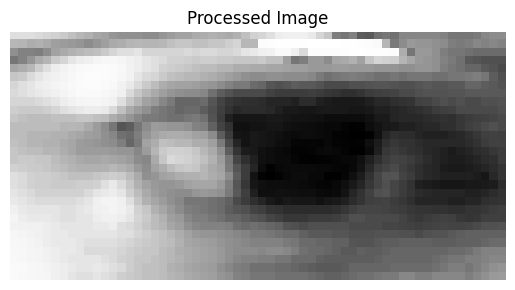

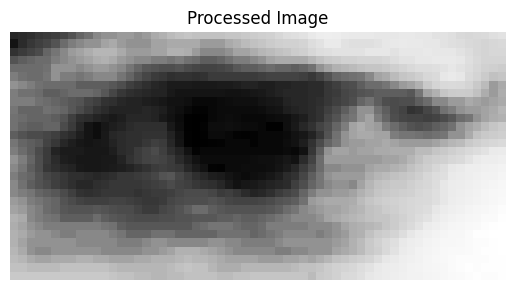

Epoch 1/100, Loss: 0.23519087433815003
Validation Loss: 0.17458975687623024
Epoch 2/100, Loss: 0.11713249236345291
Validation Loss: 0.09617022052407265
Epoch 3/100, Loss: 0.0999490886926651
Validation Loss: 0.18550223112106323
Epoch 4/100, Loss: 0.1081998810172081
Validation Loss: 0.15234197676181793
Epoch 5/100, Loss: 0.08675941675901414
Validation Loss: 0.09430540353059769
Epoch 6/100, Loss: 0.10319978594779969
Validation Loss: 0.11045980080962181
Epoch 7/100, Loss: 0.08810567557811737
Validation Loss: 0.16859716922044754
Epoch 8/100, Loss: 0.08816804438829422
Validation Loss: 0.1146930456161499
Epoch 9/100, Loss: 0.08450237810611724
Validation Loss: 0.08259129524230957
Epoch 10/100, Loss: 0.0700637273490429
Validation Loss: 0.1077631302177906
Epoch 11/100, Loss: 0.07947000116109848
Validation Loss: 0.1033635064959526
Epoch 12/100, Loss: 0.06346348971128464
Validation Loss: 0.06968623772263527
Epoch 13/100, Loss: 0.05408736951649189
Validation Loss: 0.07042106613516808
Epoch 14/100, 

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt  # Import matplotlib for displaying images

def apply_hist_eq(image):
    """
    Apply Histogram Equalization to enhance the contrast.
    """
    # Convert PIL image to numpy array if it's in PIL format
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Check if the image is in RGB format and convert to grayscale
    if len(image.shape) == 3:  # RGB format
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Histogram Equalization
    enhanced_image = cv2.equalizeHist(image)

    # Convert grayscale to RGB by replicating the same grayscale values across the three channels
    enhanced_image_rgb = cv2.cvtColor(enhanced_image, cv2.COLOR_GRAY2RGB)

    return enhanced_image_rgb

class AdvancedCNN(nn.Module):
    def __init__(self, num_outputs=2):
        super(AdvancedCNN, self).__init__()

        # Right eye pathway
        self.conv1_right = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2_right = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_right = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_right = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Left eye pathway
        self.conv1_left = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2_left = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_left = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_left = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        # Calculate the size of the feature map after convolution
        self.feature_map_size = self._get_feature_map_size(30, 60)

        # Fully connected layers after concatenating features from both eyes and yaw/pitch
        self.fc1 = nn.Linear(self.feature_map_size * 2 + 2, 1024)  # Adjusted for new feature map size + yaw/pitch input
        self.fc2 = nn.Linear(1024, num_outputs)  # Output 2 values: x and y screen positions

    def _get_feature_map_size(self, height, width):
        # Pass a dummy tensor through the network to calculate feature map size
        dummy_input = torch.ones(1, 3, height, width)
        x = self.pool(torch.relu(self.conv1_right(dummy_input)))
        x = self.pool(torch.relu(self.conv2_right(x)))
        x = self.pool(torch.relu(self.conv3_right(x)))
        x = self.pool(torch.relu(self.conv4_right(x)))
        return x.numel()  # Return the number of elements in the feature map

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Right eye pathway
        x_right = self.pool(torch.relu(self.conv1_right(right_eye_input)))
        x_right = self.pool(torch.relu(self.conv2_right(x_right)))
        x_right = self.pool(torch.relu(self.conv3_right(x_right)))
        x_right = self.pool(torch.relu(self.conv4_right(x_right)))

        # Left eye pathway
        x_left = self.pool(torch.relu(self.conv1_left(left_eye_input)))
        x_left = self.pool(torch.relu(self.conv2_left(x_left)))
        x_left = self.pool(torch.relu(self.conv3_left(x_left)))
        x_left = self.pool(torch.relu(self.conv4_left(x_left)))

        # Flatten both pathways
        x_right = x_right.view(x_right.size(0), -1)
        x_left = x_left.view(x_left.size(0), -1)

        # Concatenate features from both eyes
        x = torch.cat((x_right, x_left), dim=1)

        # Concatenate yaw/pitch with image features
        x = torch.cat((x, yaw_pitch_input), dim=1)

        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x



# Image transformations
transform = transforms.Compose([ 
    transforms.Resize((30 , 60)),  # Resize images to a consistent size
    transforms.ToTensor(),  # Convert images to tensor format
])

class GazeEstimationDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get file paths and labels
        right_eye_image_path = self.data.iloc[idx, 0]
        left_eye_image_path = self.data.iloc[idx, 1]
        yaw = self.data.iloc[idx, 2]
        roll = self.data.iloc[idx, 3]
        pitch = self.data.iloc[idx, 4]
        screen_position_x = self.data.iloc[idx, 5]
        screen_position_y = self.data.iloc[idx, 6]

        # Normalize yaw and pitch
        normalized_yaw = yaw / 40.0  # Normalize yaw to the range [-1, 1]
        normalized_pitch = pitch / 20.0  # Normalize pitch to the range [-1, 1]
        yaw_pitch_input = np.array([normalized_yaw, normalized_pitch], dtype=np.float32)

        # Load and process images
        right_eye_image = Image.open(right_eye_image_path)
        left_eye_image = Image.open(left_eye_image_path)
        
        #show_images(right_eye_image, left_eye_image)
        
        # Apply Histogram Equalization before transforming to tensor
        right_eye_image = apply_hist_eq(right_eye_image)
        left_eye_image = apply_hist_eq(left_eye_image)
        
        # Convert to PIL format before applying transformations
        right_eye_image = Image.fromarray(right_eye_image)
        left_eye_image = Image.fromarray(left_eye_image)

        # Transform images to tensor format
        if self.transform:
            right_eye_image = self.transform(right_eye_image)
            left_eye_image = self.transform(left_eye_image)

        # Labels for regression (screen positions)
        labels = np.array([screen_position_x, screen_position_y], dtype=np.float32)

        return right_eye_image, left_eye_image, torch.tensor(labels), torch.tensor(yaw_pitch_input)


# Custom split function
def split_dataset(dataset, test_size=0.2, random_state=42):
    # Split the indices of the dataset
    total_size = len(dataset)
    indices = np.arange(total_size)
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    # Calculate split sizes
    test_size = int(total_size * test_size)
    train_size = total_size - test_size
    
    # Split the indices into train and test
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # Create subsets for training and validation
    train_subset = torch.utils.data.Subset(dataset, train_indices)
    val_subset = torch.utils.data.Subset(dataset, val_indices)
    
    return train_subset, val_subset


# Training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    criterion = nn.MSELoss()  # Mean squared error loss
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in train_loader:
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass with yaw_pitch_input
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update model weights

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

        # Validate the model
        validate_model(model, val_loader)

# Validation of the model
def validate_model(model, val_loader):
    criterion = nn.MSELoss()  # Mean squared error loss
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in val_loader:  # Unpack 4 values
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass with yaw_pitch_input
            loss = criterion(outputs, labels)  # Calculate loss
            total_loss += loss.item()

    print(f"Validation Loss: {total_loss/len(val_loader)}")
    
# Function to display images
def show_processed_image(image_tensor):
    """
    Function to display a processed image.
    Args:
    - image_tensor (torch.Tensor): The image tensor after transformations.
    """
    # Convert the tensor from (C, H, W) to (H, W, C)
    image_np = image_tensor.permute(1, 2, 0).cpu().numpy()

    # Ensure the values are in the range [0, 1] for display
    image_np = np.clip(image_np, 0, 1)

    # Plot the image
    plt.imshow(image_np)
    plt.title('Processed Image')
    plt.axis('off')  # Hide axes
    plt.show()
    
def train_gaze_estimation_model(csv_file, num_epochs=100, batch_size=32, learning_rate=1e-4, model_save_path="gaze_estimation_model.pth"):
    """
    Function to train the gaze estimation model.
    
    Args:
        csv_file (str): Path to the CSV file containing the calibration data.
        num_epochs (int): Number of epochs to train the model (default 100).
        batch_size (int): Batch size for training and validation (default 32).
        learning_rate (float): Learning rate for the optimizer (default 1e-4).
        model_save_path (str): Path to save the trained model (default "gaze_estimation_model.pth").
    """
    # Check if CSV file is None or empty
    if csv_file is None or not os.path.exists(csv_file) or os.path.getsize(csv_file) == 0:
        print(f"Error: The provided CSV file '{csv_file}' is either None, does not exist, or is empty.")
        return

    # Image transformations
    transform = transforms.Compose([ 
        transforms.Resize((30 , 60)),  # Resize images to a consistent size
        transforms.ToTensor(),  # Convert images to tensor format
    ])

    # Load the dataset
    dataset = GazeEstimationDataset(csv_file=csv_file, transform=transform)
    
    right_eye_image, left_eye_image, _, _ = dataset[0]
    
    show_processed_image(right_eye_image)
    show_processed_image(left_eye_image)
    
    # Split the dataset into training and validation sets
    train_data, val_data = split_dataset(dataset)
    
    # Create DataLoader for training and validation
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    
    # Initialize the model
    model = AdvancedCNN(num_outputs=2)  # 2 outputs: x, y screen positions
    
    # Define the loss function and optimizer
    criterion = nn.MSELoss()  # Mean squared error loss
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Train the model
    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs)
    
    # Save the trained model
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")
    
    
train_gaze_estimation_model(csv_file= r'C:\BIGGEST_EYE\Learning_Curves\PFLD_GhostOne-main\FYP_LemWaiPing\calibration_results\calibration_data.csv', num_epochs=100, batch_size=32, learning_rate=1e-4, model_save_path="gaze_estimation_model.pth")


In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Updated model with MobileNetV2
class GazeEstimationWithMobileNet(nn.Module):
    def __init__(self, num_outputs=2):
        super(GazeEstimationWithMobileNet, self).__init__()

        # Use a pretrained MobileNetV2 model for feature extraction
        self.mobilenet = models.mobilenet_v2(pretrained=True)
        
        # Remove the fully connected layers to use MobileNet as a feature extractor
        self.mobilenet = nn.Sequential(*list(self.mobilenet.children())[:-1])  # Removing the last FC layer

        # Calculate input size dynamically by checking the output of MobileNetV2 with an image size of (30, 60)
        dummy_input = torch.randn(1, 3, 30, 60)  # Example input with image size 30x60
        mobilenet_output = self.mobilenet(dummy_input)
        print(f"MobileNetV2 output shape: {mobilenet_output.shape}")  # Check output shape

        # The feature map size after MobileNetV2
        feature_size = mobilenet_output.size(1) * mobilenet_output.size(2) * mobilenet_output.size(3)

        # Final fully connected layers for gaze estimation
        self.fc1 = nn.Linear(feature_size * 2 + 2, 1024)  # 2 is for yaw/pitch input, *2 for right/left eyes
        self.fc2 = nn.Linear(1024, num_outputs)

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Extract features using MobileNetV2 (using right and left eye images independently)
        right_features = self.mobilenet(right_eye_input)
        left_features = self.mobilenet(left_eye_input)

        # Flatten the features and concatenate
        right_features = right_features.view(right_features.size(0), -1)
        left_features = left_features.view(left_features.size(0), -1)
        
        # Concatenate features from both eyes
        features = torch.cat((right_features, left_features), dim=1)
        
        # Concatenate yaw/pitch input with features from both eyes
        features = torch.cat((features, yaw_pitch_input), dim=1)
        
        # Fully connected layers
        x = torch.relu(self.fc1(features))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x
    

# Image transformations
transform = transforms.Compose([ 
    transforms.Resize((30, 60)),  # Resize images to a consistent size
    transforms.ToTensor(),  # Convert images to tensor format
])

# Optimized Dataset Class
class GazeEstimationDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get file paths and labels
        right_eye_image_path = self.data.iloc[idx, 0]
        left_eye_image_path = self.data.iloc[idx, 1]
        yaw = self.data.iloc[idx, 2]
        pitch = self.data.iloc[idx, 4]
        screen_position_x = self.data.iloc[idx, 5]
        screen_position_y = self.data.iloc[idx, 6]

        # Normalize yaw and pitch
        normalized_yaw = yaw / 40.0  # Normalize yaw to the range [-1, 1]
        normalized_pitch = pitch / 20.0  # Normalize pitch to the range [-1, 1]
        yaw_pitch_input = np.array([normalized_yaw, normalized_pitch], dtype=np.float32)

        # Load and process images
        right_eye_image = Image.open(right_eye_image_path).convert("RGB")
        left_eye_image = Image.open(left_eye_image_path).convert("RGB")

        # Apply transformations
        if self.transform:
            right_eye_image = self.transform(right_eye_image)
            left_eye_image = self.transform(left_eye_image)

        # Labels for regression (screen positions)
        labels = np.array([screen_position_x, screen_position_y], dtype=np.float32)

        return right_eye_image, left_eye_image, torch.tensor(labels), torch.tensor(yaw_pitch_input)


# Custom split function for training and validation
def split_dataset(dataset, test_size=0.2, random_state=42):
    total_size = len(dataset)
    indices = np.arange(total_size)
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    test_size = int(total_size * test_size)
    train_size = total_size - test_size
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    train_subset = torch.utils.data.Subset(dataset, train_indices)
    val_subset = torch.utils.data.Subset(dataset, val_indices)
    
    return train_subset, val_subset

# Training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    criterion = nn.MSELoss()  # Mean squared error loss
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in train_loader:
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update model weights

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

        # Validate the model
        validate_model(model, val_loader)

# Validation of the model
def validate_model(model, val_loader):
    criterion = nn.MSELoss()  # Mean squared error loss
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in val_loader:
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            total_loss += loss.item()

    print(f"Validation Loss: {total_loss/len(val_loader)}")

# Train the gaze estimation model
def train_gaze_estimation_model(csv_file, num_epochs=50, batch_size=32, learning_rate=1e-4, model_save_path="gaze_estimation_model.pth"):
    # Check if CSV file is None or empty
    if csv_file is None or not os.path.exists(csv_file) or os.path.getsize(csv_file) == 0:
        print(f"Error: The provided CSV file '{csv_file}' is either None, does not exist, or is empty.")
        return

    # Image transformations
    transform = transforms.Compose([ 
        transforms.Resize((30, 60)),
        transforms.ToTensor(),
    ])

    dataset = GazeEstimationDataset(csv_file=csv_file, transform=transform)
    train_data, val_data = split_dataset(dataset)
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    
    model = GazeEstimationWithMobileNet(num_outputs=2)  # Using MobileNetV2
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs)
    
    # Save the trained model
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

# Example training
train_gaze_estimation_model(csv_file= r'C:\BIGGEST_EYE\Learning_Curves\PFLD_GhostOne-main\FYP_LemWaiPing\calibration_results\calibration_data.csv', num_epochs=50, batch_size=32, learning_rate=1e-4, model_save_path="gaze_estimation_model.pth")


In [5]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Squeeze-and-Excitation (SE) Block
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.fc1 = nn.Linear(in_channels, in_channels // reduction, bias=False)
        self.fc2 = nn.Linear(in_channels // reduction, in_channels, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        batch_size, channels, _, _ = x.size()
        y = x.mean(dim=(2, 3), keepdim=True)  # Global Average Pooling
        y = y.view(batch_size, channels)
        
        y = self.fc1(y)
        y = self.fc2(y)
        y = self.sigmoid(y).view(batch_size, channels, 1, 1)  # Reshape to match input shape
        
        return x * y  # Apply attention to the feature map

# Updated model with SE block and ResNet50
class GazeEstimationWithResNetAndSE(nn.Module):
    def __init__(self, num_outputs=2):
        super(GazeEstimationWithResNetAndSE, self).__init__()

        # Use a pretrained ResNet50 model for feature extraction
        self.resnet = models.resnet50(pretrained=True)
        
        # Remove the fully connected layers to use ResNet as a feature extractor
        self.resnet = nn.Sequential(*list(self.resnet.children())[:-2])  # Removing FC layer and AdaptiveAvgPool layer

        # Add Squeeze-and-Excitation block after the ResNet backbone
        self.se_block = SEBlock(2048)  # ResNet50 outputs 2048 channels

        # Calculate input size dynamically by checking the output of ResNet50 with an image size of (30, 60)
        dummy_input = torch.randn(1, 3, 30, 60)  # Example input with image size 30x60
        resnet_output = self.resnet(dummy_input)
        print(f"ResNet output shape: {resnet_output.shape}")  # Check output shape

        # The feature map size after ResNet50 and SE block
        # This value will depend on the image size and ResNet50's architecture
        feature_size = resnet_output.size(1) * resnet_output.size(2) * resnet_output.size(3)

        # Fully connected layers for gaze estimation
        self.fc1 = nn.Linear(feature_size * 2 + 2, 1024)  # 2 is for yaw/pitch input, *2 for right/left eyes
        self.fc2 = nn.Linear(1024, num_outputs)

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Extract features using ResNet (using right and left eye images independently)
        right_features = self.resnet(right_eye_input)
        left_features = self.resnet(left_eye_input)
        
        # Apply SE block for channel-wise attention
        right_features = self.se_block(right_features)
        left_features = self.se_block(left_features)

        # Flatten the features and concatenate
        right_features = right_features.view(right_features.size(0), -1)
        left_features = left_features.view(left_features.size(0), -1)
        
        # Concatenate features from both eyes
        features = torch.cat((right_features, left_features), dim=1)
        
        # Concatenate yaw/pitch input with features from both eyes
        features = torch.cat((features, yaw_pitch_input), dim=1)
        
        # Fully connected layers
        x = torch.relu(self.fc1(features))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x
    

# Image transformations
transform = transforms.Compose([ 
    transforms.Resize((30, 60)),  # Resize images to a consistent size
    transforms.ToTensor(),  # Convert images to tensor format
])

class GazeEstimationDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get file paths and labels
        right_eye_image_path = self.data.iloc[idx, 0]
        left_eye_image_path = self.data.iloc[idx, 1]
        yaw = self.data.iloc[idx, 2]
        roll = self.data.iloc[idx, 3]
        pitch = self.data.iloc[idx, 4]
        screen_position_x = self.data.iloc[idx, 5]
        screen_position_y = self.data.iloc[idx, 6]

        # Normalize yaw and pitch
        normalized_yaw = yaw / 40.0  # Normalize yaw to the range [-1, 1]
        normalized_pitch = pitch / 20.0  # Normalize pitch to the range [-1, 1]
        yaw_pitch_input = np.array([normalized_yaw, normalized_pitch], dtype=np.float32)

        # Load and process images
        right_eye_image = Image.open(right_eye_image_path)
        left_eye_image = Image.open(left_eye_image_path)
        
        # Apply Histogram Equalization before transforming to tensor
        right_eye_image = apply_hist_eq(right_eye_image)
        left_eye_image = apply_hist_eq(left_eye_image)
        
        # Convert the numpy array back to PIL format (after Histogram Equalization)
        right_eye_image = Image.fromarray(right_eye_image)
        left_eye_image = Image.fromarray(left_eye_image)

        # Transform images to tensor format
        if self.transform:
            right_eye_image = self.transform(right_eye_image)
            left_eye_image = self.transform(left_eye_image)

        # Labels for regression (screen positions)
        labels = np.array([screen_position_x, screen_position_y], dtype=np.float32)

        return right_eye_image, left_eye_image, torch.tensor(labels), torch.tensor(yaw_pitch_input)

# Custom split function
def split_dataset(dataset, test_size=0.2, random_state=42):
    total_size = len(dataset)
    indices = np.arange(total_size)
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    test_size = int(total_size * test_size)
    train_size = total_size - test_size
    
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    train_subset = torch.utils.data.Subset(dataset, train_indices)
    val_subset = torch.utils.data.Subset(dataset, val_indices)
    
    return train_subset, val_subset

# Training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    criterion = nn.MSELoss()  # Mean squared error loss
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in train_loader:
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update model weights

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

        # Validate the model
        validate_model(model, val_loader)

# Validation of the model
def validate_model(model, val_loader):
    criterion = nn.MSELoss()  # Mean squared error loss
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in val_loader:
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            total_loss += loss.item()

    print(f"Validation Loss: {total_loss/len(val_loader)}")

# Train the gaze estimation model
def train_gaze_estimation_model(csv_file, num_epochs=100, batch_size=32, learning_rate=1e-4, model_save_path="gaze_estimation_model.pth"):
    # Check if CSV file is None or empty
    if csv_file is None or not os.path.exists(csv_file) or os.path.getsize(csv_file) == 0:
        print(f"Error: The provided CSV file '{csv_file}' is either None, does not exist, or is empty.")
        return

    # Image transformations
    transform = transforms.Compose([ 
        transforms.Resize((30, 60)),
        transforms.ToTensor(),
    ])

    dataset = GazeEstimationDataset(csv_file=csv_file, transform=transform)
    train_data, val_data = split_dataset(dataset)
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
    
    model = GazeEstimationWithResNetAndSE(num_outputs=2)  # Using ResNet50 with SE Block
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=num_epochs)
    
    # Save the trained model
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

# Train the model (example)
train_gaze_estimation_model(csv_file= r'C:\BIGGEST_EYE\Learning_Curves\PFLD_GhostOne-main\FYP_LemWaiPing\calibration_results\calibration_data.csv', num_epochs=50, batch_size=32, learning_rate=1e-4, model_save_path="gaze_estimation_model.pth")


ResNet output shape: torch.Size([1, 2048, 1, 2])
Epoch 1/50, Loss: 0.3369685212771098
Validation Loss: 0.16562217473983765
Epoch 2/50, Loss: 0.1290419896443685
Validation Loss: 0.06469196081161499
Epoch 3/50, Loss: 0.10256523142258327
Validation Loss: 0.38048580288887024
Epoch 4/50, Loss: 0.05044714485605558
Validation Loss: 0.5078468322753906
Epoch 5/50, Loss: 0.04895427326361338
Validation Loss: 0.4359007477760315
Epoch 6/50, Loss: 0.0484932865947485
Validation Loss: 0.17177307605743408
Epoch 7/50, Loss: 0.029992240791519482
Validation Loss: 0.15421637892723083
Epoch 8/50, Loss: 0.016650868269304436
Validation Loss: 0.11513793468475342
Epoch 9/50, Loss: 0.024421727284789085
Validation Loss: 0.19918835163116455
Epoch 10/50, Loss: 0.024846745965381462
Validation Loss: 0.3464939594268799
Epoch 11/50, Loss: 0.024202955265839893
Validation Loss: 0.22967565059661865
Epoch 12/50, Loss: 0.03787748826046785
Validation Loss: 0.10867595672607422
Epoch 13/50, Loss: 0.012935400940477848
Validatio

Gaze estimation tracking

In [ ]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt  # Import matplotlib for displaying images

def apply_hist_eq(image):
    """
    Apply Histogram Equalization to enhance the contrast.
    """
    # Convert PIL image to numpy array if it's in PIL format
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Check if the image is in RGB format and convert to grayscale
    if len(image.shape) == 3:  # RGB format
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Histogram Equalization
    enhanced_image = cv2.equalizeHist(image)

    # Convert grayscale to RGB by replicating the same grayscale values across the three channels
    enhanced_image_rgb = cv2.cvtColor(enhanced_image, cv2.COLOR_GRAY2RGB)

    return enhanced_image_rgb

def show_images(right_eye_image, left_eye_image):
    """
    Function to display processed eye images using matplotlib.
    Args:
    - right_eye_image (PIL.Image or np.ndarray): Right eye image to display.
    - left_eye_image (PIL.Image or np.ndarray): Left eye image to display.
    """
    # Apply Histogram Equalization to both images
    right_eye_enhanced = apply_hist_eq(right_eye_image)
    left_eye_enhanced = apply_hist_eq(left_eye_image)

    # Ensure both images are in RGB format
    if len(right_eye_enhanced.shape) == 2:  # Grayscale
        right_eye_enhanced_rgb = cv2.cvtColor(right_eye_enhanced, cv2.COLOR_GRAY2RGB)
    else:  # RGB format
        right_eye_enhanced_rgb = right_eye_enhanced

    if len(left_eye_enhanced.shape) == 2:  # Grayscale
        left_eye_enhanced_rgb = cv2.cvtColor(left_eye_enhanced, cv2.COLOR_GRAY2RGB)
    else:  # RGB format
        left_eye_enhanced_rgb = left_eye_enhanced

    # Plot the images side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(right_eye_enhanced_rgb)
    axes[0].set_title('Right Eye Image (Enhanced)')
    axes[0].axis('off')  # Hide axes

    axes[1].imshow(left_eye_enhanced_rgb)
    axes[1].set_title('Left Eye Image (Enhanced)')
    axes[1].axis('off')  # Hide axes

    plt.show()

class SimpleCNN(nn.Module):
    def __init__(self, num_outputs=2):  # We predict screen_position_x and screen_position_y
        super(SimpleCNN, self).__init__()

        # Right eye pathway
        self.conv1_right = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2_right = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3_right = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Left eye pathway
        self.conv1_left = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2_left = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3_left = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # Calculate the size of the feature map after convolution
        self.feature_map_size = self._get_feature_map_size(30, 60)

        # Fully connected layers after concatenating features from both eyes and yaw/pitch
        self.fc1 = nn.Linear(self.feature_map_size * 2 + 2, 512)  # Adjusted for new feature map size + yaw/pitch input
        self.fc2 = nn.Linear(512, num_outputs)  # Output 2 values: x and y screen positions

    def _get_feature_map_size(self, height, width):
        # Pass a dummy tensor through the network to calculate feature map size
        dummy_input = torch.ones(1, 3, height, width)
        x = self.pool(torch.relu(self.conv1_right(dummy_input)))
        x = self.pool(torch.relu(self.conv2_right(x)))
        x = self.pool(torch.relu(self.conv3_right(x)))
        return x.numel()  # Return the number of elements in the feature map

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Right eye pathway
        x_right = self.pool(torch.relu(self.conv1_right(right_eye_input)))
        x_right = self.pool(torch.relu(self.conv2_right(x_right)))
        x_right = self.pool(torch.relu(self.conv3_right(x_right)))

        # Left eye pathway
        x_left = self.pool(torch.relu(self.conv1_left(left_eye_input)))
        x_left = self.pool(torch.relu(self.conv2_left(x_left)))
        x_left = self.pool(torch.relu(self.conv3_left(x_left)))

        # Flatten both pathways
        x_right = x_right.view(x_right.size(0), -1)
        x_left = x_left.view(x_left.size(0), -1)

        # Concatenate features from both eyes
        x = torch.cat((x_right, x_left), dim=1)

        # Concatenate yaw/pitch with image features
        x = torch.cat((x, yaw_pitch_input), dim=1)

        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x


# Image transformations
transform = transforms.Compose([ 
    transforms.Resize((30 , 60)),  # Resize images to a consistent size
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Random color jittering
    transforms.ToTensor(),  # Convert images to tensor format
])



# Custom split function
def split_dataset(dataset, test_size=0.2, random_state=42):
    # Split the indices of the dataset
    total_size = len(dataset)
    indices = np.arange(total_size)
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    # Calculate split sizes
    test_size = int(total_size * test_size)
    train_size = total_size - test_size
    
    # Split the indices into train and test
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # Create subsets for training and validation
    train_subset = torch.utils.data.Subset(dataset, train_indices)
    val_subset = torch.utils.data.Subset(dataset, val_indices)
    
    return train_subset, val_subset

# Load the dataset and split into training and validation sets
csv_file = r'C:\BIGGEST_EYE\Learning_Curves\PFLD_GhostOne-main\FYP_LemWaiPing\calibration_results\calibration_data.csv'
dataset = GazeEstimationDataset(csv_file=csv_file, transform=transform)

# Split the dataset into training and validation sets
train_data, val_data = split_dataset(dataset)

# Create DataLoader for training and validation
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# Initialize the model
model = SimpleCNN(num_outputs=2)  # 2 outputs: x, y screen positions


# Training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in train_loader:
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass with yaw_pitch_input
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update model weights

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

        # Validate the model
        validate_model(model, val_loader)

# Validation of the model
def validate_model(model, val_loader):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in val_loader:  # Unpack 4 values
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass with yaw_pitch_input
            loss = criterion(outputs, labels)  # Calculate loss
            total_loss += loss.item()

    print(f"Validation Loss: {total_loss/len(val_loader)}")


# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean squared error loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50)

# Save the trained model
torch.save(model.state_dict(), "simple_gaze_estimation_model.pth")


Epoch 1/50, Loss: 0.2560282498598099
Validation Loss: 0.11396407335996628
Epoch 2/50, Loss: 0.11448056399822235


KeyboardInterrupt: 

In [79]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt  # Import matplotlib for displaying images

def apply_hist_eq(image):
    """
    Apply Histogram Equalization to enhance the contrast.
    """
    # Convert PIL image to numpy array if it's in PIL format
    if isinstance(image, Image.Image):
        image = np.array(image)

    # Check if the image is in RGB format and convert to grayscale
    if len(image.shape) == 3:  # RGB format
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Apply Histogram Equalization
    enhanced_image = cv2.equalizeHist(image)

    # Convert grayscale to RGB by replicating the same grayscale values across the three channels
    enhanced_image_rgb = cv2.cvtColor(enhanced_image, cv2.COLOR_GRAY2RGB)

    return enhanced_image_rgb

def show_images(right_eye_image, left_eye_image):
    """
    Function to display processed eye images using matplotlib.
    Args:
    - right_eye_image (PIL.Image or np.ndarray): Right eye image to display.
    - left_eye_image (PIL.Image or np.ndarray): Left eye image to display.
    """
    # Apply Histogram Equalization to both images
    right_eye_enhanced = apply_hist_eq(right_eye_image)
    left_eye_enhanced = apply_hist_eq(left_eye_image)

    # Ensure both images are in RGB format
    if len(right_eye_enhanced.shape) == 2:  # Grayscale
        right_eye_enhanced_rgb = cv2.cvtColor(right_eye_enhanced, cv2.COLOR_GRAY2RGB)
    else:  # RGB format
        right_eye_enhanced_rgb = right_eye_enhanced

    if len(left_eye_enhanced.shape) == 2:  # Grayscale
        left_eye_enhanced_rgb = cv2.cvtColor(left_eye_enhanced, cv2.COLOR_GRAY2RGB)
    else:  # RGB format
        left_eye_enhanced_rgb = left_eye_enhanced

    # Plot the images side by side
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    axes[0].imshow(right_eye_enhanced_rgb)
    axes[0].set_title('Right Eye Image (Enhanced)')
    axes[0].axis('off')  # Hide axes

    axes[1].imshow(left_eye_enhanced_rgb)
    axes[1].set_title('Left Eye Image (Enhanced)')
    axes[1].axis('off')  # Hide axes

    plt.show()

class AdvancedCNN(nn.Module):
    def __init__(self, num_outputs=2):
        super(AdvancedCNN, self).__init__()

        # Right eye pathway
        self.conv1_right = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2_right = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_right = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_right = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Left eye pathway
        self.conv1_left = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2_left = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3_left = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv4_left = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        # Calculate the size of the feature map after convolution
        self.feature_map_size = self._get_feature_map_size(30, 60)

        # Fully connected layers after concatenating features from both eyes and yaw/pitch
        self.fc1 = nn.Linear(self.feature_map_size * 2 + 2, 1024)  # Adjusted for new feature map size + yaw/pitch input
        self.fc2 = nn.Linear(1024, num_outputs)  # Output 2 values: x and y screen positions

    def _get_feature_map_size(self, height, width):
        # Pass a dummy tensor through the network to calculate feature map size
        dummy_input = torch.ones(1, 3, height, width)
        x = self.pool(torch.relu(self.conv1_right(dummy_input)))
        x = self.pool(torch.relu(self.conv2_right(x)))
        x = self.pool(torch.relu(self.conv3_right(x)))
        x = self.pool(torch.relu(self.conv4_right(x)))
        return x.numel()  # Return the number of elements in the feature map

    def forward(self, right_eye_input, left_eye_input, yaw_pitch_input):
        # Right eye pathway
        x_right = self.pool(torch.relu(self.conv1_right(right_eye_input)))
        x_right = self.pool(torch.relu(self.conv2_right(x_right)))
        x_right = self.pool(torch.relu(self.conv3_right(x_right)))
        x_right = self.pool(torch.relu(self.conv4_right(x_right)))

        # Left eye pathway
        x_left = self.pool(torch.relu(self.conv1_left(left_eye_input)))
        x_left = self.pool(torch.relu(self.conv2_left(x_left)))
        x_left = self.pool(torch.relu(self.conv3_left(x_left)))
        x_left = self.pool(torch.relu(self.conv4_left(x_left)))

        # Flatten both pathways
        x_right = x_right.view(x_right.size(0), -1)
        x_left = x_left.view(x_left.size(0), -1)

        # Concatenate features from both eyes
        x = torch.cat((x_right, x_left), dim=1)

        # Concatenate yaw/pitch with image features
        x = torch.cat((x, yaw_pitch_input), dim=1)

        # Fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # Output 2 values: x and y screen positions

        return x



# Image transformations
transform = transforms.Compose([ 
    transforms.Resize((30 , 60)),  # Resize images to a consistent size
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Random color jittering
    transforms.ToTensor(),  # Convert images to tensor format
])

class GazeEstimationDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get file paths and labels
        right_eye_image_path = self.data.iloc[idx, 0]
        left_eye_image_path = self.data.iloc[idx, 1]
        yaw = self.data.iloc[idx, 2]
        roll = self.data.iloc[idx, 3]
        pitch = self.data.iloc[idx, 4]
        screen_position_x = self.data.iloc[idx, 5]
        screen_position_y = self.data.iloc[idx, 6]

        # Normalize yaw and pitch
        normalized_yaw = yaw / 40.0  # Normalize yaw to the range [-1, 1]
        normalized_pitch = pitch / 20.0  # Normalize pitch to the range [-1, 1]
        yaw_pitch_input = np.array([normalized_yaw, normalized_pitch], dtype=np.float32)

        # Load and process images
        right_eye_image = Image.open(right_eye_image_path)
        left_eye_image = Image.open(left_eye_image_path)
        
        #show_images(right_eye_image, left_eye_image)
        
        # Apply Histogram Equalization before transforming to tensor
        right_eye_image = apply_hist_eq(right_eye_image)
        left_eye_image = apply_hist_eq(left_eye_image)
        
        # Convert to PIL format before applying transformations
        right_eye_image = Image.fromarray(right_eye_image)
        left_eye_image = Image.fromarray(left_eye_image)

        # Transform images to tensor format
        if self.transform:
            right_eye_image = self.transform(right_eye_image)
            left_eye_image = self.transform(left_eye_image)

        # Labels for regression (screen positions)
        labels = np.array([screen_position_x, screen_position_y], dtype=np.float32)

        return right_eye_image, left_eye_image, torch.tensor(labels), torch.tensor(yaw_pitch_input)


# Custom split function
def split_dataset(dataset, test_size=0.2, random_state=42):
    # Split the indices of the dataset
    total_size = len(dataset)
    indices = np.arange(total_size)
    np.random.seed(random_state)
    np.random.shuffle(indices)
    
    # Calculate split sizes
    test_size = int(total_size * test_size)
    train_size = total_size - test_size
    
    # Split the indices into train and test
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    # Create subsets for training and validation
    train_subset = torch.utils.data.Subset(dataset, train_indices)
    val_subset = torch.utils.data.Subset(dataset, val_indices)
    
    return train_subset, val_subset


# Training the model
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in train_loader:
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass with yaw_pitch_input
            loss = criterion(outputs, labels)  # Calculate loss
            loss.backward()  # Backward pass
            optimizer.step()  # Update model weights

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader)}")

        # Validate the model
        validate_model(model, val_loader)

# Validation of the model
def validate_model(model, val_loader):
    model.eval()  # Set the model to evaluation mode
    total_loss = 0.0
    with torch.no_grad():
        for right_eye_image, left_eye_image, labels, yaw_pitch_input in val_loader:  # Unpack 4 values
            outputs = model(right_eye_image, left_eye_image, yaw_pitch_input)  # Forward pass with yaw_pitch_input
            loss = criterion(outputs, labels)  # Calculate loss
            total_loss += loss.item()

    print(f"Validation Loss: {total_loss/len(val_loader)}")
    
    
# Load the dataset and split into training and validation sets
csv_file = r'C:\BIGGEST_EYE\Learning_Curves\PFLD_GhostOne-main\FYP_LemWaiPing\calibration_results\calibration_data.csv'
dataset = GazeEstimationDataset(csv_file=csv_file, transform=transform)

# Split the dataset into training and validation sets
train_data, val_data = split_dataset(dataset)

# Create DataLoader for training and validation
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

# Initialize the model
model = AdvancedCNN(num_outputs=2)  # 2 outputs: x, y screen positions

# Define the loss function and optimizer
criterion = nn.MSELoss()  # Mean squared error loss
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=100)

# Save the trained model
torch.save(model.state_dict(), "gaze_estimation_model.pth")


Epoch 1/100, Loss: 0.17210898122617177
Validation Loss: 0.06944650411605835
Epoch 2/100, Loss: 0.08115011613283839
Validation Loss: 0.0627291090786457
Epoch 3/100, Loss: 0.07100727462342807
Validation Loss: 0.04836813919246197
Epoch 4/100, Loss: 0.06373782668794904
Validation Loss: 0.04526842199265957
Epoch 5/100, Loss: 0.06362767836877278
Validation Loss: 0.04371968284249306
Epoch 6/100, Loss: 0.06227906101516315
Validation Loss: 0.04366646707057953
Epoch 7/100, Loss: 0.0612492880650929
Validation Loss: 0.04386625811457634
Epoch 8/100, Loss: 0.05982665824038642
Validation Loss: 0.04206474497914314
Epoch 9/100, Loss: 0.05755883348839624
Validation Loss: 0.042316706851124763
Epoch 10/100, Loss: 0.0566409985933985
Validation Loss: 0.040188346058130264
Epoch 11/100, Loss: 0.05189342264618192
Validation Loss: 0.043121980503201485
Epoch 12/100, Loss: 0.05281314307025501
Validation Loss: 0.04141348972916603
Epoch 13/100, Loss: 0.050939224128212245
Validation Loss: 0.03474816679954529
Epoch 1